# DNA Methylation Analysis with `minfi`

This notebook presents an exploratory analysis of an eight-sample whole-blood subset from **GSE174555**, comparing four children with Down syndrome (`DIS`) with four typically developing controls (`CTRL`). The samples were profiled on the Illumina HumanMethylation450 BeadChip.

### Authorship and contribution

This analysis was completed collaboratively as a **Group 9 course project**. My assigned individual responsibility was **Step 3: extracting fluorescence values for address `72769420` and identifying its probe information**.

This portfolio adaptation corrects the dataset description, PCA interpretation, probe filtering, small-sample variance setting, and differential-analysis scale. The original course notebook is preserved separately.

## Dataset and analytical scope

The complete GEO series contains 34 whole-blood samples: 17 children with Down syndrome and 17 typically developing children. This course subset contains eight of those samples.

The analysis is intentionally exploratory. With only eight samples, partial sex imbalance, and no adjustment for blood-cell composition or other covariates, the results must not be interpreted as causal findings or validated biomarkers.

In [1]:
# Install missing packages, then load the analysis environment.
options(repos = c(CRAN = "https://cloud.r-project.org"))

if (!requireNamespace("BiocManager", quietly = TRUE)) {
  install.packages("BiocManager")
}

bioc_packages <- c(
  "minfi",
  "IlluminaHumanMethylation450kmanifest",
  "IlluminaHumanMethylation450kanno.ilmn12.hg19"
)
cran_packages <- c("ggplot2", "pheatmap")

for (pkg in bioc_packages) {
  if (!requireNamespace(pkg, quietly = TRUE)) {
    BiocManager::install(pkg, ask = FALSE, update = FALSE)
  }
}
for (pkg in cran_packages) {
  if (!requireNamespace(pkg, quietly = TRUE)) {
    install.packages(pkg)
  }
}

suppressPackageStartupMessages({
  library(minfi)
  library(IlluminaHumanMethylation450kmanifest)
  library(IlluminaHumanMethylation450kanno.ilmn12.hg19)
  library(ggplot2)
  library(pheatmap)
})

options(width = 110, repr.plot.width = 8, repr.plot.height = 6)
set.seed(9)

cat("minfi version:", as.character(packageVersion("minfi")), "\n")

minfi version: 1.58.0


## 1. Import the raw methylation data

In [2]:
# The public repository does not include raw IDAT files.
# Place Input_Data_Files.zip beside this notebook before running it.
data_dir <- "raw_data"
zip_path <- "Input_Data_Files.zip"

if (!dir.exists(data_dir)) {
  if (!file.exists(zip_path)) {
    stop("Input_Data_Files.zip was not found beside the notebook.")
  }
  unzip(zip_path, exdir = data_dir)
}

sheet_path <- list.files(
  data_dir,
  pattern = "SampleSheet_Report_II\\.csv$",
  full.names = TRUE,
  recursive = TRUE
)
if (length(sheet_path) != 1L) {
  stop("Expected exactly one SampleSheet_Report_II.csv file.")
}

base_dir <- dirname(sheet_path)
targets <- read.metharray.sheet(
  base = base_dir,
  pattern = "SampleSheet_Report_II\\.csv$"
)

missing_files <- unlist(lapply(targets$Basename, function(basename_value) {
  candidates <- paste0(basename_value, c("_Red.idat", "_Grn.idat"))
  candidates[!file.exists(candidates)]
}))
if (length(missing_files) > 0L) {
  stop("One or more required red/green IDAT files are missing.")
}

RGset <- read.metharray.exp(targets = targets)
pheno <- as.data.frame(pData(RGset))

cat("Samples:", ncol(RGset), "\n")
cat("Raw addresses:", nrow(RGset), "\n")
pheno[, c("SampleID", "Sex", "Group", "Slide", "Array")]


Samples: 8
Raw addresses: 622399


SampleID    Sex     Group  Slide         Array 
----------  ------  -----  ------------  ------
GSM5319592  Male    CTRL   200121140049  R01C02
GSM5319603  Male    DIS    3999356129    R02C02
GSM5319604  Female  DIS    3999547012    R02C01
GSM5319607  Male    CTRL   3999547012    R03C02
GSM5319609  Female  DIS    3999547016    R02C01
GSM5319613  Female  DIS    3999547017    R02C01
GSM5319615  Female  CTRL   3999547017    R04C01
GSM5319616  Female  CTRL   3999547017    R06C01

The subset contains four `CTRL` and four `DIS` samples. The sex distribution is two female and two male samples in `CTRL`, versus three female and one male sample in `DIS`.

## 2. Extract raw fluorescence values

In [3]:
Red <- getRed(RGset)
Green <- getGreen(RGset)

cat("Red matrix dimensions:", paste(dim(Red), collapse = " x "), "\n")
cat("Green matrix dimensions:", paste(dim(Green), collapse = " x "), "\n")

Red matrix dimensions: 622399 x 8
Green matrix dimensions: 622399 x 8


## 3. Group 9 assigned address: `72769420`

In [4]:
address_group9 <- "72769420"

stopifnot(address_group9 %in% rownames(Red))
stopifnot(address_group9 %in% rownames(Green))

manifest <- getManifest(RGset)
probe_I <- as.data.frame(getProbeInfo(manifest, type = "I"))
probe_II <- as.data.frame(getProbeInfo(manifest, type = "II"))

hit_I <- probe_I[
  as.character(probe_I$AddressA) == address_group9 |
    as.character(probe_I$AddressB) == address_group9,
]
hit_II <- probe_II[as.character(probe_II$AddressA) == address_group9, ]

if (nrow(hit_I) > 0L) {
  probe_type <- "Type I"
  probe_color <- unique(as.character(hit_I$Color))[1]
  probe_name <- unique(as.character(hit_I$Name))[1]
} else if (nrow(hit_II) > 0L) {
  probe_type <- "Type II"
  probe_color <- NA_character_
  probe_name <- unique(as.character(hit_II$Name))[1]
} else {
  stop("Assigned address was not found in the array manifest.")
}

step3_table <- data.frame(
  SampleID = pheno$SampleID,
  Group = pheno$Group,
  Sex = pheno$Sex,
  Red_fluorescence = as.numeric(Red[address_group9, ]),
  Green_fluorescence = as.numeric(Green[address_group9, ]),
  Probe_type = probe_type,
  Color = probe_color,
  Probe_name = probe_name,
  row.names = NULL
)

step3_table

SampleID    Group  Sex     Red  Green  Probe_type  Color  Probe_name
----------  -----  ------  ---  -----  ----------  -----  ----------
GSM5319592  CTRL   Male    271  1831   Type II     NA     cg01010298
GSM5319603  DIS    Male    94   552    Type II     NA     cg01010298
GSM5319604  DIS    Female  447  2778   Type II     NA     cg01010298
GSM5319607  CTRL   Male    393  2509   Type II     NA     cg01010298
GSM5319609  DIS    Female  346  1152   Type II     NA     cg01010298
GSM5319613  DIS    Female  631  3466   Type II     NA     cg01010298
GSM5319615  CTRL   Female  597  3969   Type II     NA     cg01010298
GSM5319616  CTRL   Female  500  2869   Type II     NA     cg01010298

Address `72769420` maps to the Type II probe `cg01010298`. A separate Type I color-channel assignment is therefore not applicable.

## 4. Quality control and detection p-values

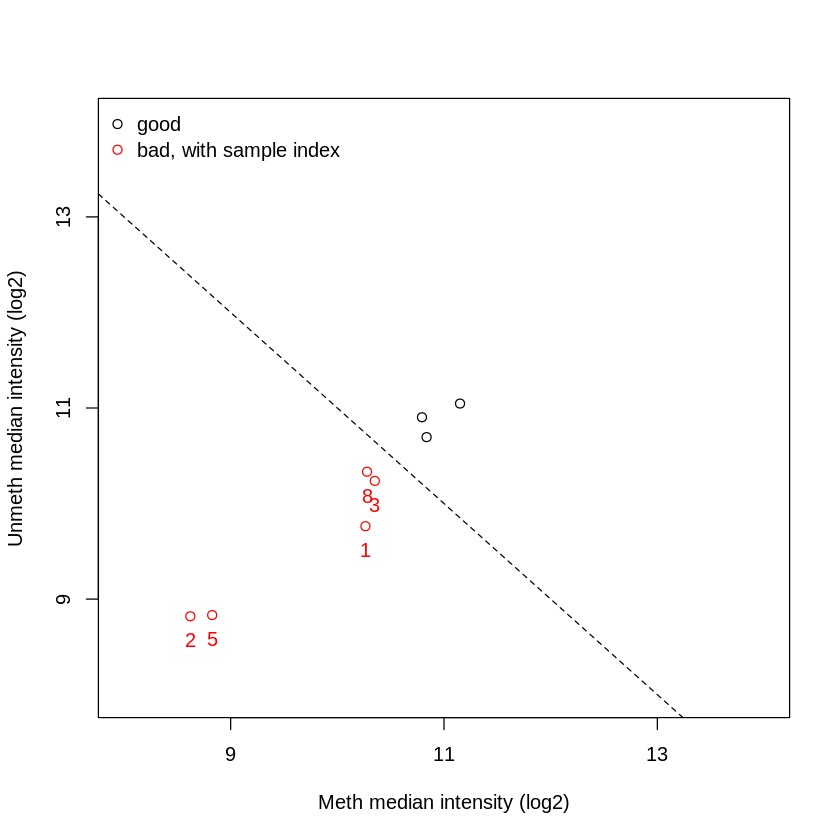

SampleID    Group  Sex     Failed_positions  Failed_percent
----------  -----  ------  ----------------  --------------
GSM5319592  CTRL   Male    202               0.042         
GSM5319603  DIS    Male    306               0.063         
GSM5319604  DIS    Female  1156              0.238         
GSM5319607  CTRL   Male    366               0.075         
GSM5319609  DIS    Female  2735              0.563         
GSM5319613  DIS    Female  460               0.095         
GSM5319615  CTRL   Female  384               0.079         
GSM5319616  CTRL   Female  674               0.139         

In [5]:
MSet.raw <- preprocessRaw(RGset)
qc_raw <- getQC(MSet.raw)
plotQC(qc_raw)

detP_threshold <- 0.05  # Course-assigned threshold for Group 9
detP <- detectionP(RGset)
failed_positions <- colSums(detP > detP_threshold, na.rm = TRUE)

failed_table <- data.frame(
  SampleID = pheno$SampleID,
  Group = pheno$Group,
  Sex = pheno$Sex,
  Failed_positions = as.integer(failed_positions),
  Failed_percent = round(100 * failed_positions / nrow(detP), 3),
  row.names = NULL
)

failed_table

All eight arrays were retained. At the assigned threshold, the failed-position percentages ranged from **0.042% to 0.563%**. Probe-level filtering is applied below so that a probe must pass the threshold in every sample used for differential testing.

## 5. `preprocessNoob` normalization and probe filtering

In [6]:
MSet.norm <- preprocessNoob(RGset)
beta_norm <- getBeta(MSet.norm)
m_norm <- getM(MSet.norm)

stopifnot(identical(rownames(beta_norm), rownames(m_norm)))
stopifnot(identical(rownames(beta_norm), rownames(detP)))

keep_detected <- rowSums(detP > detP_threshold, na.rm = TRUE) == 0L
keep_finite <- rowSums(is.finite(m_norm)) == ncol(m_norm)
keep_probe <- keep_detected & keep_finite

beta_filtered <- beta_norm[keep_probe, , drop = FALSE]
m_filtered <- m_norm[keep_probe, , drop = FALSE]

data.frame(
  Input_probes = nrow(beta_norm),
  Retained_probes = nrow(beta_filtered),
  Removed_probes = nrow(beta_norm) - nrow(beta_filtered)
)

Input_probes  Retained_probes  Removed_probes
------------  ---------------  --------------
485512        481451           4061          

Normalized M-values are used for hypothesis testing because their statistical properties are preferable for differential methylation analysis. Beta values are retained for effect-size reporting as delta beta, which is easier to interpret biologically.

## 6. Principal component analysis

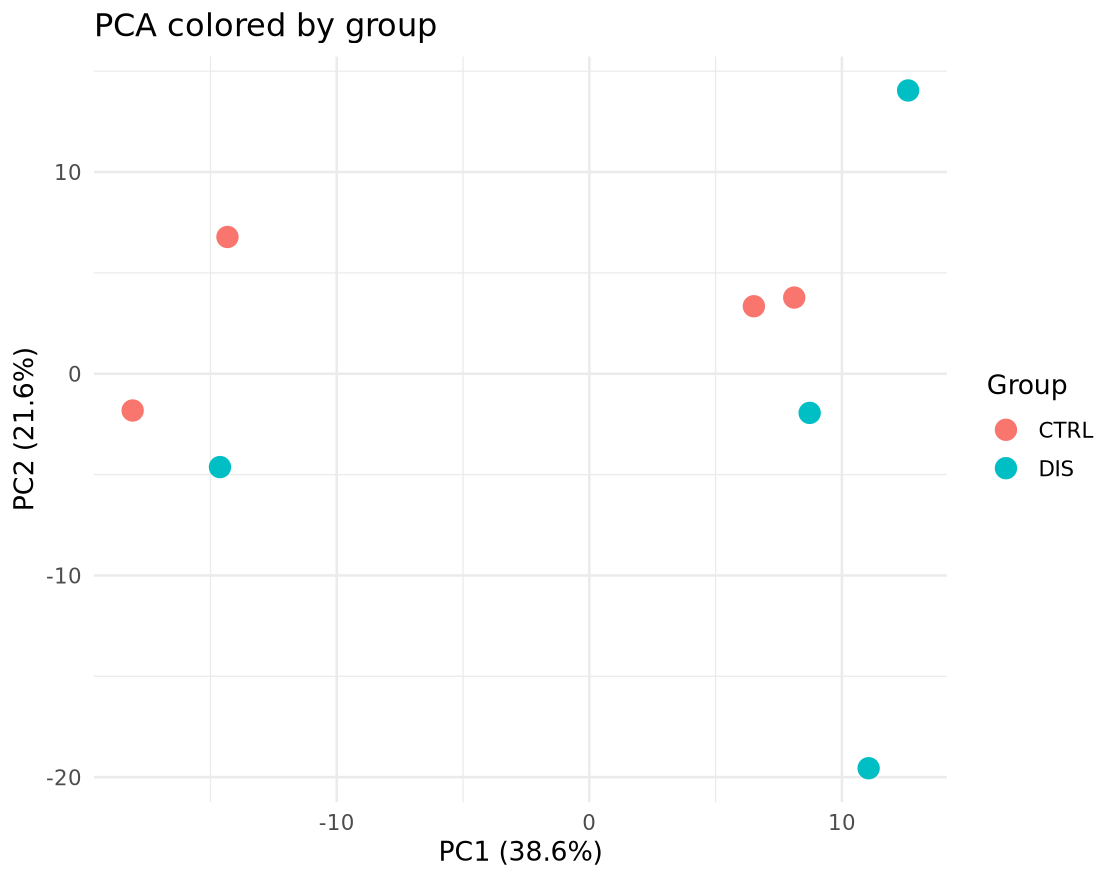

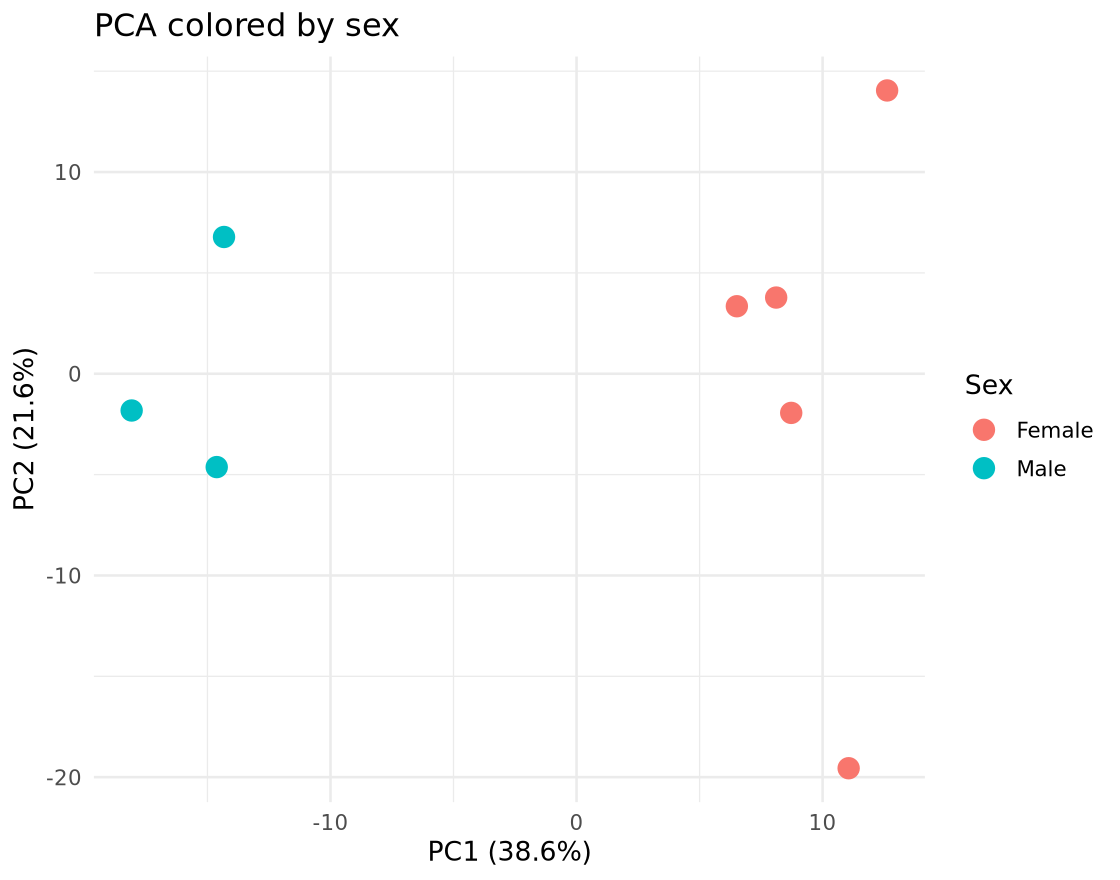

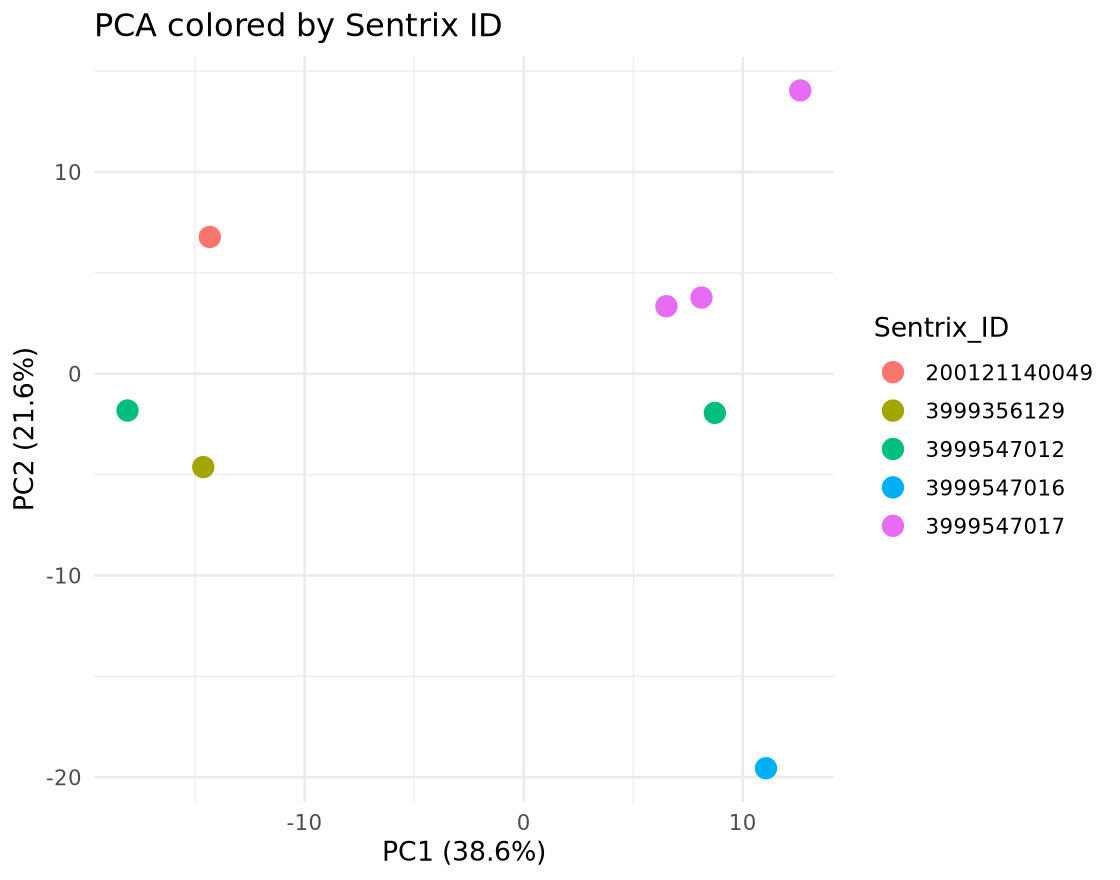

In [7]:
group <- factor(
  pheno$Group[match(colnames(beta_filtered), sampleNames(RGset))],
  levels = c("CTRL", "DIS")
)
sex <- factor(pheno$Sex[match(colnames(beta_filtered), sampleNames(RGset))])
sentrix_id <- factor(pheno$Slide[match(colnames(beta_filtered), sampleNames(RGset))])

probe_variance <- matrixStats::rowVars(beta_filtered, na.rm = TRUE)
top_variable <- order(probe_variance, decreasing = TRUE)[seq_len(10000)]

pca <- prcomp(
  t(beta_filtered[top_variable, , drop = FALSE]),
  center = TRUE,
  scale. = FALSE
)
pca_var <- 100 * (pca$sdev^2 / sum(pca$sdev^2))

pca_df <- data.frame(
  SampleID = pheno$SampleID[match(rownames(pca$x), sampleNames(RGset))],
  PC1 = pca$x[, 1],
  PC2 = pca$x[, 2],
  Group = group,
  Sex = sex,
  Sentrix_ID = sentrix_id,
  row.names = NULL
)

plot_pca <- function(color_var, title_text) {
  ggplot(pca_df, aes(x = PC1, y = PC2, color = .data[[color_var]])) +
    geom_point(size = 4) +
    labs(
      title = title_text,
      x = sprintf("PC1 (%.1f%%)", pca_var[1]),
      y = sprintf("PC2 (%.1f%%)", pca_var[2]),
      color = color_var
    ) +
    theme_minimal(base_size = 12)
}

plot_pca("Group", "PCA colored by group")
plot_pca("Sex", "PCA colored by sex")
plot_pca("Sentrix_ID", "PCA colored by Sentrix ID")

PC1 and PC2 explain **38.6%** and **21.6%** of the variance, respectively. The biological groups do not separate completely. In contrast, the samples show a clear sex-associated pattern along PC1. No simple clustering pattern by Sentrix ID is evident, although the sample size is too small to exclude technical effects.

Because sex is unevenly distributed between groups and strongly associated with the PCA structure, it is a potential confounder for the unadjusted group comparison below.

## 7. Differential methylation with `dmpFinder`

In [8]:
# dmpFinder recommends variance shrinkage for fewer than 10 samples.
# minfi may emit a harmless contrast-name warning for a two-level factor;
# the p-values are checked against the equivalent direct limma model below.
dmp <- withCallingHandlers(
  dmpFinder(
    m_filtered,
    pheno = group,
    type = "categorical",
    qCutoff = 1,
    shrinkVar = TRUE
  ),
  warning = function(w) {
    if (grepl("row names of contrasts", conditionMessage(w), fixed = TRUE)) {
      invokeRestart("muffleWarning")
    }
  }
)

design_check <- model.matrix(~ group)
fit_check <- limma::eBayes(limma::lmFit(m_filtered, design_check))
manual_p <- fit_check$p.value[, "groupDIS"]
max_p_difference <- max(abs(dmp$pval - manual_p[rownames(dmp)]), na.rm = TRUE)
stopifnot(max_p_difference < 1e-12)

mean_CTRL <- rowMeans(beta_filtered[, group == "CTRL", drop = FALSE], na.rm = TRUE)
mean_DIS <- rowMeans(beta_filtered[, group == "DIS", drop = FALSE], na.rm = TRUE)

dmp$ProbeID <- rownames(dmp)
dmp$delta_beta <- (mean_DIS - mean_CTRL)[rownames(dmp)]
dmp$BH <- p.adjust(dmp$pval, method = "BH")
dmp$bonferroni <- p.adjust(dmp$pval, method = "bonferroni")
dmp <- dmp[order(dmp$pval), , drop = FALSE]

data.frame(
  Criterion = c(
    "Nominal p < 0.05",
    "Benjamini-Hochberg FDR < 0.05",
    "Bonferroni < 0.05",
    "dmpFinder Storey q-value < 0.05"
  ),
  Significant_probes = c(
    sum(dmp$pval < 0.05, na.rm = TRUE),
    sum(dmp$BH < 0.05, na.rm = TRUE),
    sum(dmp$bonferroni < 0.05, na.rm = TRUE),
    sum(dmp$qval < 0.05, na.rm = TRUE)
  )
)

cat("Maximum validation p-value difference:", format(max_p_difference, scientific = TRUE), "\n")

Criterion                        Significant_probes
-------------------------------  ------------------
Nominal p < 0.05                 14383             
Benjamini-Hochberg FDR < 0.05    22                
Bonferroni < 0.05                4                 
dmpFinder Storey q-value < 0.05  26                

Maximum validation p-value difference: 1.474515e-17


The corrected analysis identifies **22 probes at Benjamini-Hochberg FDR < 0.05** and **4 after Bonferroni correction**. The 14,383 nominal p-values below 0.05 are not treated as evidence because they do not account for multiple testing.

These are exploratory, unadjusted associations. They may reflect sex, blood-cell composition, or other differences in this small subset and require independent validation.

## 8. Annotation of the leading probes

In [9]:
anno <- getAnnotation(MSet.norm)
anno_cols <- intersect(
  c("chr", "pos", "UCSC_RefGene_Name", "Relation_to_Island"),
  colnames(anno)
)

top_annotated <- cbind(
  dmp[1:20, c("ProbeID", "f", "pval", "qval", "BH", "bonferroni", "delta_beta")],
  as.data.frame(anno[dmp$ProbeID[1:20], anno_cols, drop = FALSE])
)

top_annotated[1:10, ]

ProbeID     p-value    BH      Bonferroni  Delta_beta  Chr    Gene                                                
----------  ---------  ------  ----------  ----------  -----  ----------------------------------------------------
cg13746854  1.644e-08  0.0079  0.0079      +0.557      chr9   KIAA1161                                            
cg18077307  8.154e-08  0.0114  0.0393      -0.589      chr2   TMEM131                                             
cg02877261  8.322e-08  0.0114  0.0401      +0.560      chr4   —                                                   
cg16054907  9.448e-08  0.0114  0.0455      +0.146      chr22  MAPK11                                              
cg24840300  1.567e-07  0.0151  0.0754      +0.292      chr19  LPPR3                                               
cg03142697  4.405e-07  0.0353  0.2121      +0.628      chr21  RUNX1;RUNX1;RUNX1                                   
cg05289022  6.875e-07  0.0384  0.3310      -0.444      chr2   TMEM131           

## 9. Differential methylation visualizations

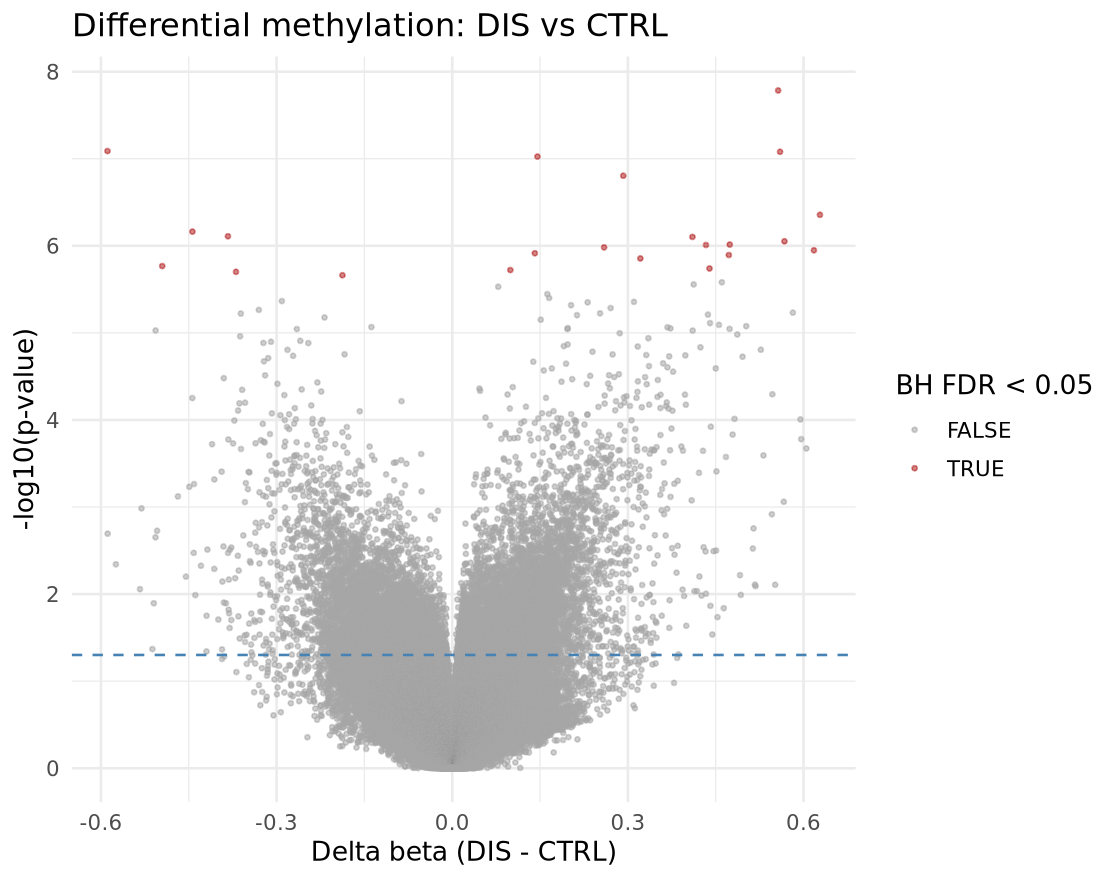

In [10]:
volcano_df <- data.frame(
  delta_beta = dmp$delta_beta,
  minus_log10_p = -log10(pmax(dmp$pval, .Machine$double.xmin)),
  significant = dmp$BH < 0.05
)

ggplot(volcano_df, aes(x = delta_beta, y = minus_log10_p, color = significant)) +
  geom_point(alpha = 0.55, size = 0.7) +
  scale_color_manual(values = c(`FALSE` = "grey65", `TRUE` = "firebrick")) +
  geom_hline(yintercept = -log10(0.05), linetype = "dashed", color = "steelblue") +
  labs(
    title = "Differential methylation: DIS vs CTRL",
    x = "Delta beta (DIS - CTRL)",
    y = "-log10(p-value)",
    color = "BH FDR < 0.05"
  ) +
  theme_minimal(base_size = 12)

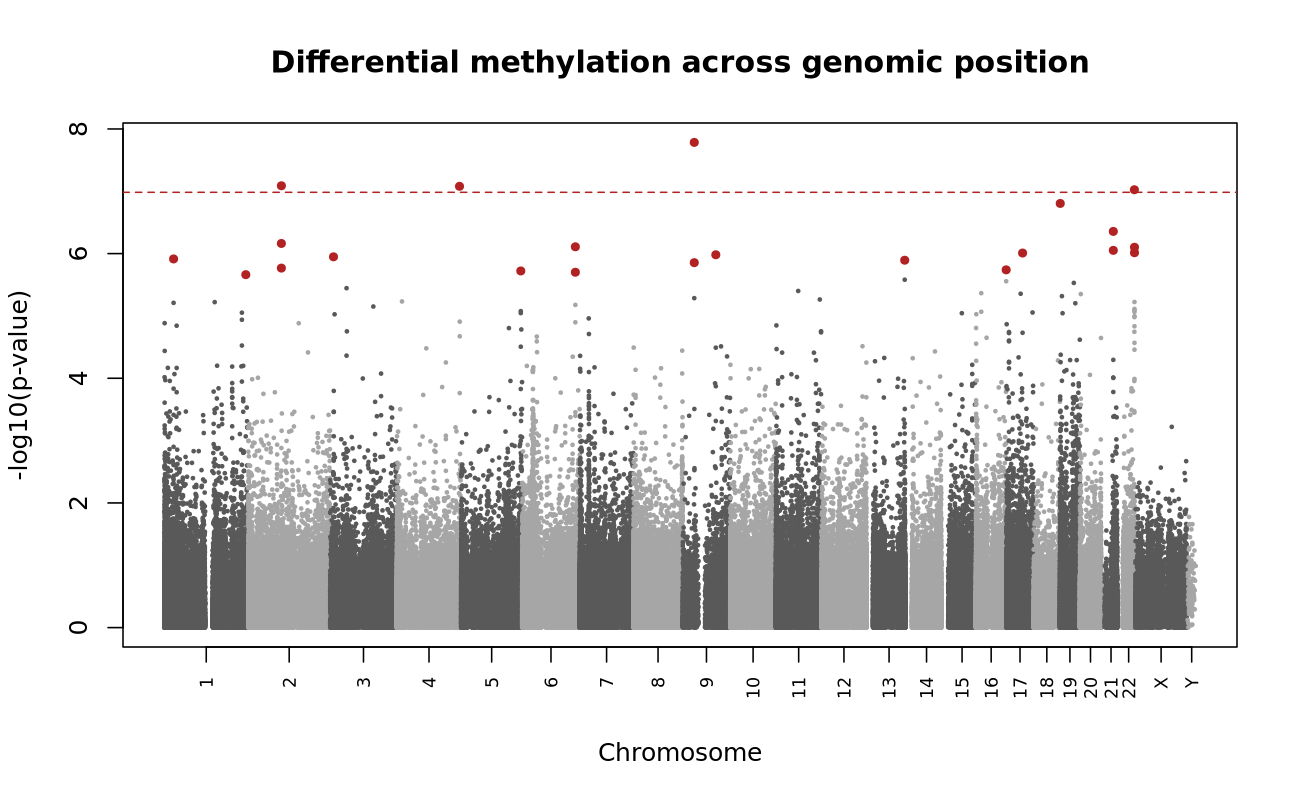

In [11]:
man <- data.frame(
  pval = dmp$pval,
  chr = anno[dmp$ProbeID, "chr"],
  pos = anno[dmp$ProbeID, "pos"],
  BH = dmp$BH,
  stringsAsFactors = FALSE
)
man <- man[!is.na(man$chr) & !is.na(man$pos), ]
man$chr <- factor(man$chr, levels = paste0("chr", c(1:22, "X", "Y")))
man <- man[!is.na(man$chr), ]
man <- man[order(man$chr, man$pos), ]
man$chr <- droplevels(man$chr)

chrs <- levels(man$chr)
max_pos <- vapply(chrs, function(cc) max(man$pos[man$chr == cc]), numeric(1))
offset <- setNames(c(0, head(cumsum(max_pos), -1)), chrs)
man$x <- man$pos + offset[as.character(man$chr)]
ticks <- vapply(chrs, function(cc) mean(range(man$x[man$chr == cc])), numeric(1))
plot_colors <- rep(c("grey35", "grey65"), length.out = length(chrs))[as.integer(man$chr)]

options(repr.plot.width = 10, repr.plot.height = 6)
plot(
  man$x,
  -log10(pmax(man$pval, .Machine$double.xmin)),
  pch = 20,
  cex = 0.42,
  col = plot_colors,
  xaxt = "n",
  xlab = "Chromosome",
  ylab = "-log10(p-value)",
  main = "Differential methylation across genomic position"
)
axis(1, at = ticks, labels = sub("chr", "", chrs), las = 2, cex.axis = 0.7)
abline(h = -log10(0.05 / nrow(dmp)), col = "firebrick", lty = 2)
points(
  man$x[man$BH < 0.05],
  -log10(man$pval[man$BH < 0.05]),
  col = "firebrick",
  pch = 20,
  cex = 1
)

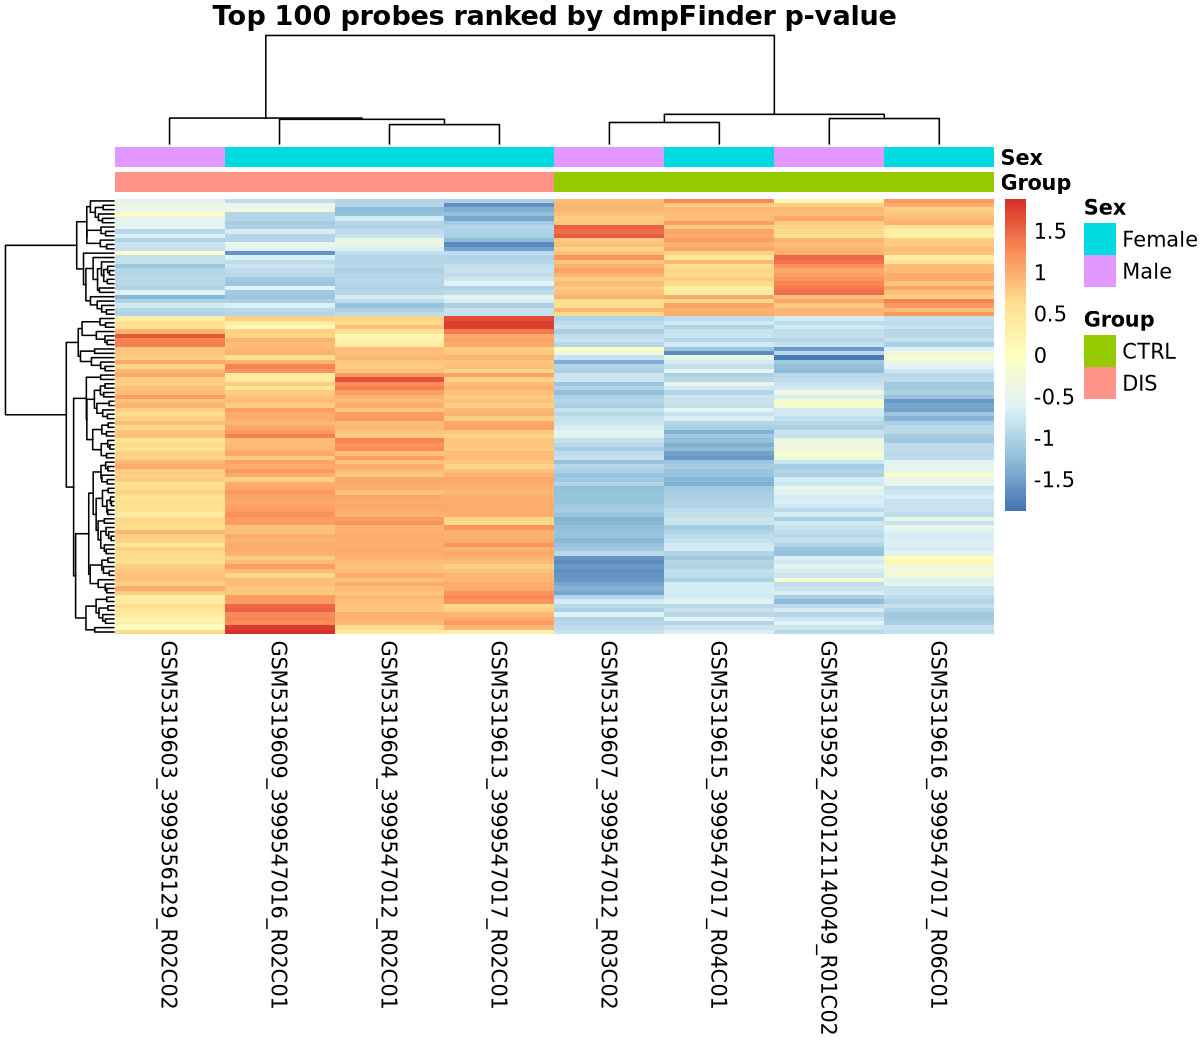

In [12]:
options(repr.plot.width = 9, repr.plot.height = 7)
top100 <- dmp$ProbeID[1:100]
heatmap_matrix <- beta_filtered[top100, , drop = FALSE]
heatmap_annotation <- data.frame(Group = group, Sex = sex)
rownames(heatmap_annotation) <- colnames(heatmap_matrix)

pheatmap(
  heatmap_matrix,
  annotation_col = heatmap_annotation,
  show_rownames = FALSE,
  scale = "row",
  clustering_method = "complete",
  main = "Top 100 probes ranked by dmpFinder p-value"
)

## Conclusion

The workflow successfully imports and processes the eight Illumina 450K arrays, performs QC and `preprocessNoob` normalization, and produces an exploratory list of differentially methylated probes. The strongest visual structure in the PCA is associated with sex, while group separation is incomplete. Accordingly, the differential results should be viewed as preliminary candidates rather than disease-specific findings.

A larger analysis should use the complete cohort, account for sex and estimated blood-cell composition, apply additional probe-quality filters, and validate findings in an independent dataset.

## References

- [GSE174555, NCBI Gene Expression Omnibus](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE174555)
- [Official `minfi` package manual](https://bioconductor.org/packages/release/bioc/manuals/minfi/man/minfi.pdf)
- Aryee et al. (2014). [`minfi`: a flexible and comprehensive Bioconductor package](https://doi.org/10.1093/bioinformatics/btu049).
- Du et al. (2010). [Comparison of beta-value and M-value methods](https://pmc.ncbi.nlm.nih.gov/articles/PMC3012676/).

In [13]:
sessionInfo()

R version 4.5.3 (2026-03-11)
Platform: x86_64-conda-linux-gnu

Key package versions:
  minfi_1.58.0
  IlluminaHumanMethylation450kmanifest_0.4.0
  IlluminaHumanMethylation450kanno.ilmn12.hg19_0.6.1
  limma_3.66.0
  ggplot2_4.0.3
  pheatmap_1.0.13